In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_excel('/content/drive/MyDrive/Untitled folder/TataIQ_Delinquency_prediction_dataset.xlsx')


In [3]:
# --- Basic EDA ---
print(df.head())
print(df.info())
print(df.describe())

  Customer_ID  Age  Imputed_Income    Income  Credit_Score  \
0    CUST0001   56        165580.0  165580.0         398.0   
1    CUST0002   69        100999.0  100999.0         493.0   
2    CUST0003   46        188416.0  188416.0         500.0   
3    CUST0004   32        101672.0  101672.0         413.0   
4    CUST0005   60         38524.0   38524.0         487.0   

   Credit_Utilization  Missed_Payments  Delinquent_Account  Loan_Balance  \
0            0.390502                3                   0       16310.0   
1            0.312444                6                   1       17401.0   
2            0.359930                0                   0       13761.0   
3            0.371400                3                   0       88778.0   
4            0.234716                2                   0       13316.0   

   Debt_to_Income_Ratio  ... Account_Tenure  Credit_Card_Type     Location  \
0              0.317396  ...             18           Student  Los Angeles   
1             

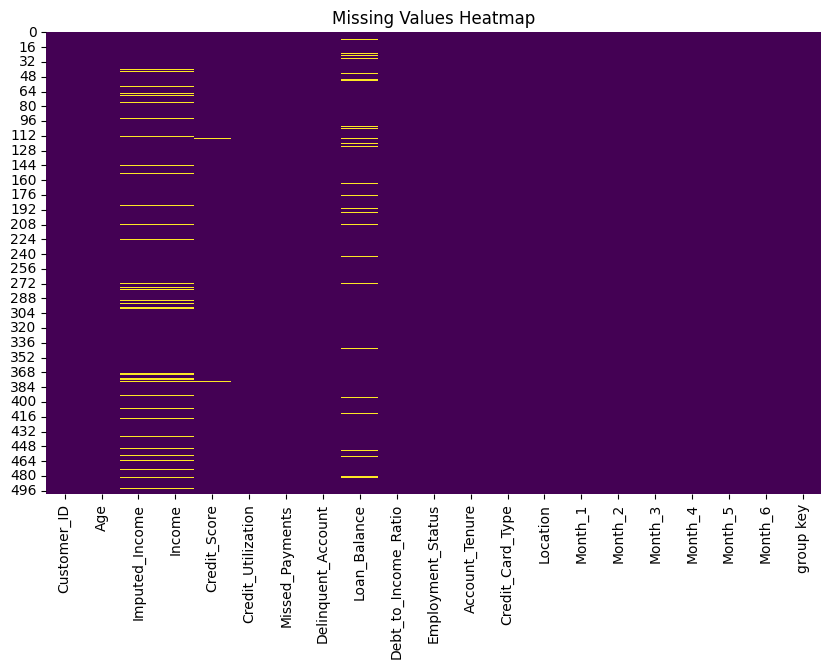

In [4]:
# --- Handle outliers ---
df['Credit_Utilization'] = df['Credit_Utilization'].clip(upper=1.0)

# --- Visualize missing values ---
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

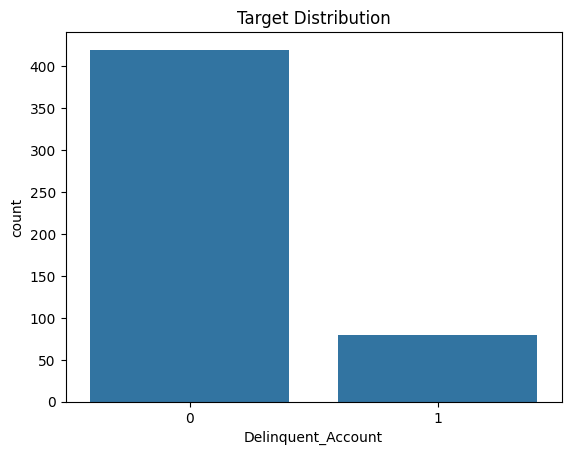

In [5]:
# --- Target distribution ---
sns.countplot(x='Delinquent_Account', data=df)
plt.title("Target Distribution")
plt.show()

In [6]:
# --- Add missing indicators ---
for col in ['Income', 'Credit_Score', 'Loan_Balance']:
    df[col + '_Missing'] = df[col].isnull().astype(int)

In [7]:
# --- Prepare for MICE ---
numerical = ['Age', 'Income', 'Credit_Score', 'Credit_Utilization', 'Missed_Payments',
             'Loan_Balance', 'Debt_to_Income_Ratio', 'Account_Tenure']
categorical = ['Employment_Status', 'Location']

# Preprocess
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical)
], remainder='passthrough')

df_for_mice = df[numerical + categorical].copy()
preprocessor.fit(df_for_mice)

encoded_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical)
all_features = list(encoded_names) + [f for f in numerical if f not in categorical]
df_encoded = pd.DataFrame(preprocessor.transform(df_for_mice), columns=all_features, index=df.index)

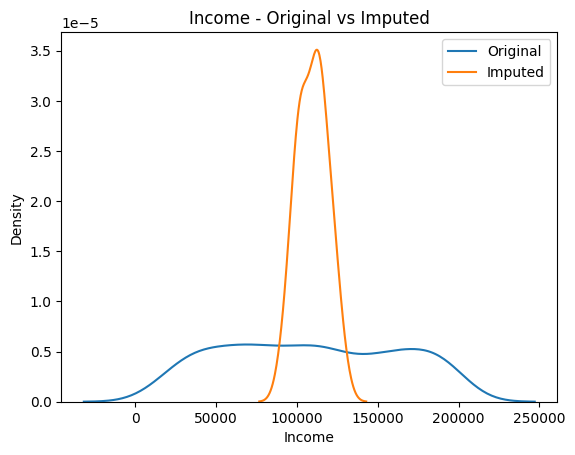

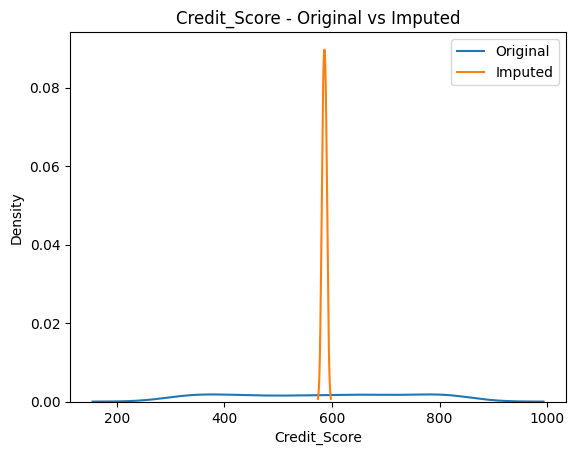

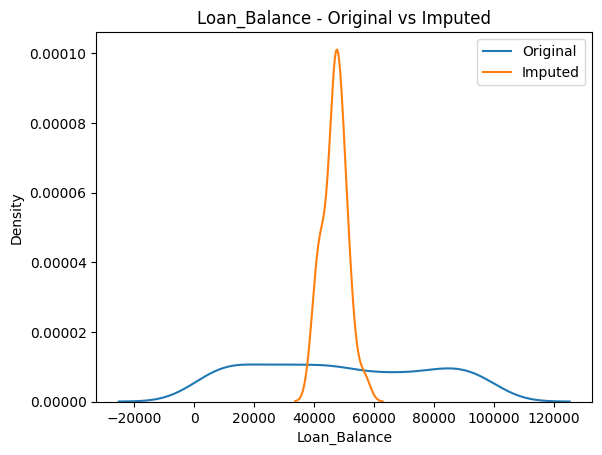

In [8]:
# --- Impute ---
imputer = IterativeImputer(estimator=LinearRegression(), max_iter=10, random_state=42)
df_imputed_array = imputer.fit_transform(df_encoded)
df_imputed = pd.DataFrame(df_imputed_array, columns=all_features, index=df.index)

for col in ['Income', 'Credit_Score', 'Loan_Balance']:
    if col in df_imputed.columns:
        df[col] = df_imputed[col]

# --- Check imputation impact ---
for col in ['Income', 'Credit_Score', 'Loan_Balance']:
    plt.figure()
    sns.kdeplot(df[df[col + '_Missing'] == 0][col], label='Original')
    sns.kdeplot(df[df[col + '_Missing'] == 1][col], label='Imputed')
    plt.title(f'{col} - Original vs Imputed')
    plt.legend()
    plt.show()

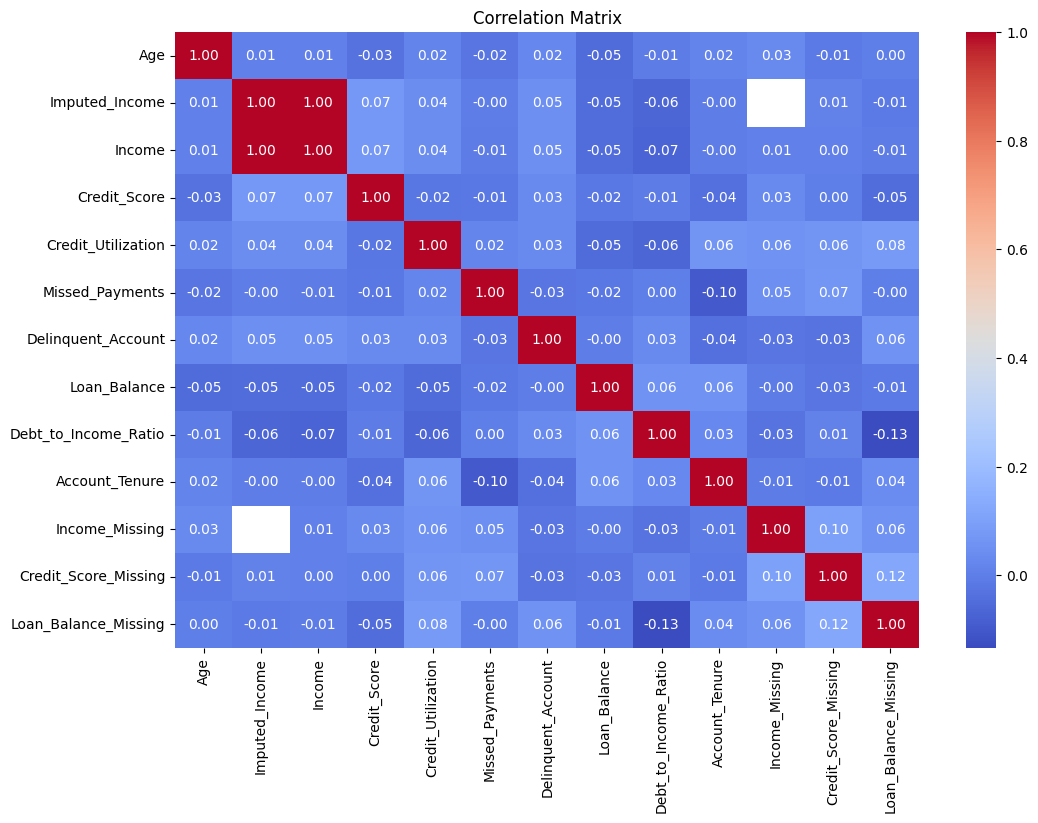

In [9]:
# --- Correlation matrix ---
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [10]:
# Identify *all* categorical columns in the original df
all_categorical_cols = ['Employment_Status', 'Location']
# Drop the original string columns that will be replaced by dummies
df = df.drop(columns=all_categorical_cols)

In [11]:
# --- Encode rest of categoricals ---
# Employment_Status and Location were already one-hot encoded during MICE preparation
# Only encode Credit_Card_Type here
cols_to_dummy = ['Credit_Card_Type','Missed_Payments','Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6']
# Ensure the columns exist before attempting to get dummies
cols_to_dummy = [col for col in cols_to_dummy if col in df.columns]
df = pd.get_dummies(df, columns=cols_to_dummy, drop_first=True)
df = df.drop(columns=['group key'])
# Add a check to see the data types and a sample of X_train after encoding
print("\nDtypes of X after encoding:")
print(df.drop(columns=['Customer_ID', 'Delinquent_Account'], errors='ignore').dtypes)
print("\nSample of X after encoding:")
print(df.drop(columns=['Customer_ID', 'Delinquent_Account'], errors='ignore').head())


Dtypes of X after encoding:
Age                            int64
Imputed_Income               float64
Income                       float64
Credit_Score                 float64
Credit_Utilization           float64
Loan_Balance                 float64
Debt_to_Income_Ratio         float64
Account_Tenure                 int64
Income_Missing                 int64
Credit_Score_Missing           int64
Loan_Balance_Missing           int64
Credit_Card_Type_Gold           bool
Credit_Card_Type_Platinum       bool
Credit_Card_Type_Standard       bool
Credit_Card_Type_Student        bool
Missed_Payments_1               bool
Missed_Payments_2               bool
Missed_Payments_3               bool
Missed_Payments_4               bool
Missed_Payments_5               bool
Missed_Payments_6               bool
Month_1_Missed                  bool
Month_1_On-time                 bool
Month_2_Missed                  bool
Month_2_On-time                 bool
Month_3_Missed                  bool
Month_3_O

              precision    recall  f1-score   support

           0       0.84      1.00      0.91       105
           1       0.00      0.00      0.00        20

    accuracy                           0.84       125
   macro avg       0.42      0.50      0.46       125
weighted avg       0.71      0.84      0.77       125

ROC AUC Score: 0.37642857142857145


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


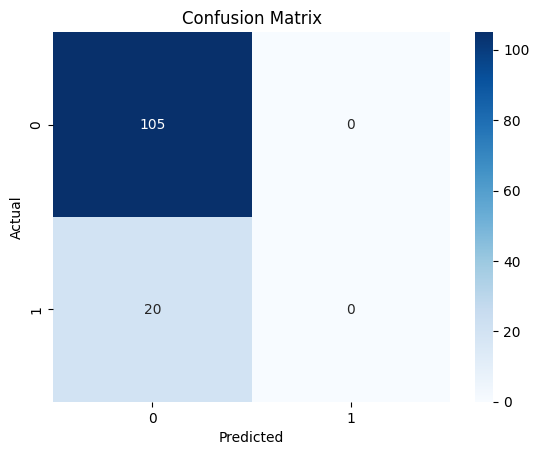

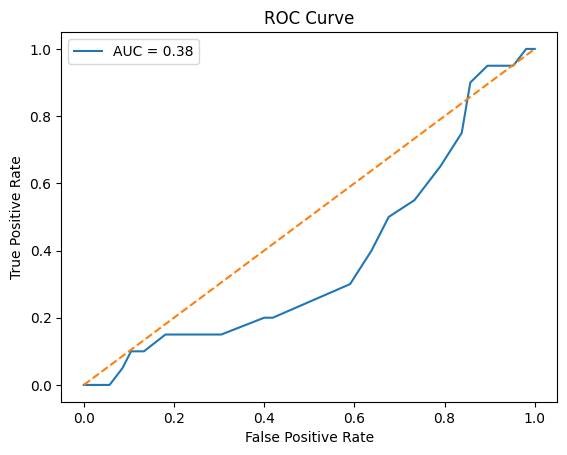

In [12]:
# --- Train-test split ---
X = df.drop(columns=['Customer_ID', 'Delinquent_Account'])
y = df['Delinquent_Account']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.25, random_state=42)

# --- Train model ---
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# --- Evaluate ---
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [14]:
import joblib

# After you have successfully trained your pipeline, for example:
# gradient_boosting_smote_pipeline.fit(X_train, y_train)

# Choose which pipeline to save
model_to_save = model # Or logistic_regression_smote_pipeline

# Define a filename for your saved model
filename = 'delinquency_prediction_model.joblib'

# Save the entire pipeline to a file
joblib.dump(model_to_save, filename)

print(f"Model saved as {filename}")

Model saved as delinquency_prediction_model.joblib


In [15]:
# using the model on new data
# Define the filename where your model is saved
filename = 'delinquency_prediction_model.joblib'

try:
    # Load the trained pipeline from the file
    loaded_model = joblib.load(filename)
    print("Model loaded successfully!")

    # Now, simulate a new dataset (ensure it has the same raw columns as your original df)
    # This is dummy data, replace with your actual new input data
    new_customer_data = pd.DataFrame({
        'Age': [35, 48],
        'Imputed_Income': [75000.0, 120000.0],
        'Imputed_Credit_Score': [650.0, 720.0],
        'Income': [75000.0, 120000.0],
        'Credit_Score': [650.0, 720.0],
        'Credit_Utilization': [0.5, 0.85], # Example: one with high utilization
        'Missed_Payments': [1, 3], # Example: one with more missed payments
        'Loan_Balance': [None, 30000.0], # Example: one with missing loan balance
        'Debt_to_Income_Ratio': [0.25, 0.45],
        'Employment_Status': ['Employed', 'Unemployed'],
        'Account_Tenure': [10, 5],
        'Credit_Card_Type': ['Standard', 'Business'], # Example: one with Business card
        'Location': ['New York', 'Los Angeles'],
        'Month_1': ['On-time', 'Late'],
        'Month_2': ['On-time', 'Missed'],
        'Month_3': ['On-time', 'On-time'],
        'Month_4': ['On-time', 'Late'],
        'Month_5': ['On-time', 'Missed'],
        'Month_6': ['On-time', 'On-time'],
    })

    # You need to ensure the `Income_Missing`, `Credit_Score_Missing`, `Loan_Balance_Missing`
    # and `Month_X_Binary` columns are created *before* passing to the loaded pipeline.
    # The pipeline only preprocesses the features it expects, not creates new ones based on raw data.
    # So, you must replicate the feature engineering steps for *new* data.

    # Replicate feature engineering for new data:
    new_customer_data['Credit_Utilization'] = new_customer_data['Credit_Utilization'].apply(lambda x: 1.0 if x > 1.0 else x)
    new_customer_data['Income_Missing'] = new_customer_data['Income'].isnull().astype(int)
    new_customer_data['Credit_Score_Missing'] = new_customer_data['Credit_Score'].isnull().astype(int)
    new_customer_data['Loan_Balance_Missing'] = new_customer_data['Loan_Balance'].isnull().astype(int)

    payment_mapping = {'On-time': 0, 'Missed': 1, 'Late': 1}
    for col in ['Month_1', 'Month_2', 'Month_3', 'Month_4', 'Month_5', 'Month_6']:
        new_customer_data[f'{col}_Binary'] = new_customer_data[col].map(payment_mapping)
    new_customer_data['Total_Missed_Late_Payments'] = new_customer_data[[f'Month_{i}_Binary' for i in range(1, 7)]].sum(axis=1)

    # Now, make predictions using the loaded model
    predictions = loaded_model.predict(new_customer_data)
    probabilities = loaded_model.predict_proba(new_customer_data)[:, 1]

    print("\nPredictions for new customers:")
    for i, pred in enumerate(predictions):
        status = "Delinquent" if pred == 1 else "Not Delinquent"
        print(f"Customer {i+1}: Predicted Status = {status}, Probability of Delinquency = {probabilities[i]:.4f}")

except FileNotFoundError:
    print(f"Error: Model file '{filename}' not found. Please ensure it's saved in the correct directory.")
except Exception as e:
    print(f"An error occurred: {e}")

Model loaded successfully!
An error occurred: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Credit_Card_Type
- Employment_Status
- Location
- Missed_Payments
- Month_1
- ...
Feature names seen at fit time, yet now missing:
- Credit_Card_Type_Gold
- Credit_Card_Type_Platinum
- Credit_Card_Type_Standard
- Credit_Card_Type_Student
- Imputed_Income
- ...

